# Comparaison ERM vs Data Augmentation
Simulation de la performance de différentes fonctions de perte (Logistic, Hinge, Squared)
sur un modèle source et des modèles cibles (hôpitaux), avec et sans augmentation de données.

## 1. Imports et configuration

In [1]:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Make sure local modules are importable
ROOT = pathlib.Path().resolve() / "Empirical-risk-minimization-asymptotics"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- Import project code ---
import data_models as dm
import losses_regularizers as lr
import erm_theory as et
import data_augmentation as augm

## 2. Paramètres globaux

In [2]:
rng_train = np.random.default_rng(0)
rng_test  = np.random.default_rng(1)

n_train = 50
n_test  = 2000
p       = 30
m       = 1
sigma   = 1

# Paramètres de l'hôpital cible
theta_e = 0.1
s_e     = 0.1

# Paramètres de l'augmentation
rho  = 0.1
beta = 0.1

# Régularisation
lam = 0.1

## 3. Fonctions utilitaires

In [3]:
def generate_source_model(p, delta, sigma, gamma_pos=0.5):
    C = sigma**2 * np.eye(p)
    e1 = np.zeros(p)
    e1[0] = 1.0
    mu_pos = delta * e1
    mu_neg = -delta * e1
    x_neg = dm.GaussianModel(p=p, mu=mu_neg, C=C)
    x_pos = dm.GaussianModel(p=p, mu=mu_pos, C=C)
    return dm.MultiClassModel(
        components=[x_neg, x_pos],
        gamma=[1.0 - gamma_pos, gamma_pos],
        y_values=[-1.0, +1.0],
    )


def generate_target_model(p, delta, sigma, rotation, biais, gamma_pos=0.5):
    C = sigma**2 * np.eye(p)
    e1 = np.zeros(p)
    e1[0] = 1.0
    mu_pos = delta * e1
    mu_neg = -delta * e1
    mean_pos = (rotation @ mu_pos) + biais
    mean_neg = (rotation @ mu_neg) + biais
    x_neg = dm.GaussianModel(p=p, mu=mean_neg, C=C)
    x_pos = dm.GaussianModel(p=p, mu=mean_pos, C=C)
    return dm.MultiClassModel(
        components=[x_neg, x_pos],
        gamma=[1.0 - gamma_pos, gamma_pos],
        y_values=[-1.0, +1.0],
    )


def rotation(theta, p):
    R = np.eye(p)
    R[0, 0] =  np.cos(theta)
    R[0, 1] = -np.sin(theta)
    R[1, 0] =  np.sin(theta)
    R[1, 1] =  np.cos(theta)
    return R


def random_rotation_from_identity(n, rng, theta=1.0):
    """
    Generate a random rotation matrix at 'distance' theta from identity.
    theta=0 → Identity matrix
    theta large → Far from identity
    """
    A = rng.standard_normal((n, n))
    K = (A - A.T) / 2  # skew-symmetric part
    K = K / np.linalg.norm(K, ord='fro')
    return expm(theta * K)


def make_transform(p, rho, beta, rng):
    def transform(X):
        R_eps = random_rotation_from_identity(p, rng=rng, theta=rho)
        eps   = R_eps - np.eye(p)
        eta   = rng.uniform(-beta, beta, size=p)
        return X @ (np.eye(p) + eps).T + eta
    return transform

## 4. Définition des modèles et de la régularisation

In [4]:
loss1 = lr.LogisticLoss()
loss2 = lr.HingeLoss()
loss3 = lr.SquaredLoss()

reg = lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))

R_e = rotation(theta_e, p)
b_e = np.zeros(p)
b_e[1] = s_e

model_train = generate_source_model(sigma=sigma, p=p, delta=m)
model_test  = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)

## 5. Entraînement ERM (sans augmentation)

In [5]:
# Logistic loss
trainer1 = et.ERMTrainer(model=model_train, loss=loss1, regularizer=reg)
theta_hat1, _, _ = trainer1.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

# Hinge loss
trainer2 = et.ERMTrainer(model=model_train, loss=loss2, regularizer=reg)
theta_hat2, _, _ = trainer2.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

# Squared loss
trainer3 = et.ERMTrainer(model=model_train, loss=loss3, regularizer=reg)
theta_hat3, _, _ = trainer3.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

## 6. Évaluation ERM — source et 1 hôpital cible

In [6]:
erreur_log_source     = model_train.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test)
erreur_hinge_source   = model_train.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test)
erreur_squared_source = model_train.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test)

erreur_log     = model_test.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test)
erreur_hinge   = model_test.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test)
erreur_squared = model_test.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test)

print("=== ERM — Erreurs source ===")
print(f"  Logistic : {erreur_log_source:.4f}")
print(f"  Hinge    : {erreur_hinge_source:.4f}")
print(f"  Squared  : {erreur_squared_source:.4f}")
print("\n=== ERM — Erreurs 1 hôpital cible ===")
print(f"  Logistic : {erreur_log:.4f}")
print(f"  Hinge    : {erreur_hinge:.4f}")
print(f"  Squared  : {erreur_squared:.4f}")

=== ERM — Erreurs source ===
  Logistic : 0.2670
  Hinge    : 0.2575
  Squared  : 0.2370

=== ERM — Erreurs 1 hôpital cible ===
  Logistic : 0.2680
  Hinge    : 0.2495
  Squared  : 0.2370


## 7. Évaluation ERM — moyenne sur 100 hôpitaux

In [7]:
nb_hopit = 100
erreur_log_final = erreur_hinge_final = erreur_squared_final = 0.0
theta = theta_e
s = s_e

for i in range(nb_hopit):
    theta += 0.002
    s += 0.002
    R_e = rotation(theta, p)
    b_e = np.zeros(p)
    b_e[1] = s
    mt = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)
    erreur_log_final     += mt.error_classif_emp([theta_hat1], n_test=n_test, rng=rng_test)
    erreur_hinge_final   += mt.error_classif_emp([theta_hat2], n_test=n_test, rng=rng_test)
    erreur_squared_final += mt.error_classif_emp([theta_hat3], n_test=n_test, rng=rng_test)

print("=== ERM — Moyenne 100 hôpitaux ===")
print(f"  Logistic : {erreur_log_final/nb_hopit:.4f}")
print(f"  Hinge    : {erreur_hinge_final/nb_hopit:.4f}")
print(f"  Squared  : {erreur_squared_final/nb_hopit:.4f}")

=== ERM — Moyenne 100 hôpitaux ===
  Logistic : 0.2751
  Hinge    : 0.2641
  Squared  : 0.2286


## 8. Entraînement avec augmentation de données

In [8]:
transform = make_transform(p, rho, beta, rng_train)

# Logistic loss
trainer1_augm = augm.DataAugmTrainer(model=model_train, loss=loss1, regularizer=reg,
                                     transform=transform)
theta_hat1_augm, _, _ = trainer1_augm.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

# Hinge loss
trainer2_augm = augm.DataAugmTrainer(model=model_train, loss=loss2, regularizer=reg,
                                     transform=transform)
theta_hat2_augm, _, _ = trainer2_augm.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

# Squared loss
trainer3_augm = augm.DataAugmTrainer(model=model_train, loss=loss3, regularizer=reg,
                                     transform=transform)
theta_hat3_augm, _, _ = trainer3_augm.sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=180)

## 9. Évaluation Augmentation — source et 1 hôpital cible

In [9]:
# Recréer le modèle cible de référence
R_e = rotation(theta_e, p)
b_e = np.zeros(p)
b_e[1] = s_e
model_test = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)

erreur_log_source_augm     = model_train.error_classif_emp([theta_hat1_augm], n_test=n_test, rng=rng_test)
erreur_hinge_source_augm   = model_train.error_classif_emp([theta_hat2_augm], n_test=n_test, rng=rng_test)
erreur_squared_source_augm = model_train.error_classif_emp([theta_hat3_augm], n_test=n_test, rng=rng_test)

erreur_log_augm     = model_test.error_classif_emp([theta_hat1_augm], n_test=n_test, rng=rng_test)
erreur_hinge_augm   = model_test.error_classif_emp([theta_hat2_augm], n_test=n_test, rng=rng_test)
erreur_squared_augm = model_test.error_classif_emp([theta_hat3_augm], n_test=n_test, rng=rng_test)

print("=== Augmentation — Erreurs source ===")
print(f"  Logistic : {erreur_log_source_augm:.4f}")
print(f"  Hinge    : {erreur_hinge_source_augm:.4f}")
print(f"  Squared  : {erreur_squared_source_augm:.4f}")
print("\n=== Augmentation — Erreurs 1 hôpital cible ===")
print(f"  Logistic : {erreur_log_augm:.4f}")
print(f"  Hinge    : {erreur_hinge_augm:.4f}")
print(f"  Squared  : {erreur_squared_augm:.4f}")

=== Augmentation — Erreurs source ===
  Logistic : 0.2055
  Hinge    : 0.2405
  Squared  : 0.2650

=== Augmentation — Erreurs 1 hôpital cible ===
  Logistic : 0.2080
  Hinge    : 0.2655
  Squared  : 0.2695


## 10. Évaluation Augmentation — moyenne sur 100 hôpitaux

In [10]:
nb_hopit2 = 100
erreur_log_final_augm = erreur_hinge_final_augm = erreur_squared_final_augm = 0.0
theta = theta_e
s = s_e

for i in range(nb_hopit2):
    theta += 0.002
    s += 0.002
    R_e = rotation(theta, p)
    b_e = np.zeros(p)
    b_e[1] = s
    mt = generate_target_model(sigma=sigma, p=p, delta=m, rotation=R_e, biais=b_e)
    erreur_log_final_augm     += mt.error_classif_emp([theta_hat1_augm], n_test=n_test, rng=rng_test)
    erreur_hinge_final_augm   += mt.error_classif_emp([theta_hat2_augm], n_test=n_test, rng=rng_test)
    erreur_squared_final_augm += mt.error_classif_emp([theta_hat3_augm], n_test=n_test, rng=rng_test)

print("=== Augmentation — Moyenne 100 hôpitaux ===")
print(f"  Logistic : {erreur_log_final_augm/nb_hopit2:.4f}")
print(f"  Hinge    : {erreur_hinge_final_augm/nb_hopit2:.4f}")
print(f"  Squared  : {erreur_squared_final_augm/nb_hopit2:.4f}")

=== Augmentation — Moyenne 100 hôpitaux ===
  Logistic : 0.2126
  Hinge    : 0.2597
  Squared  : 0.2827


## 11. Tableau récapitulatif HTML

In [11]:
html = (
    "<!DOCTYPE html>\n"
    "<html>\n"
    "<head>\n"
    "<meta charset='utf-8'>\n"
    "<style>\n"
    "body { font-family: Arial, sans-serif; margin: 40px; }\n"
    "h2 { color: #333; }\n"
    ".params { background: #f5f5f5; padding: 10px; border-radius: 6px; margin-bottom: 20px; }\n"
    "table { border-collapse: collapse; width: 100%; }\n"
    "th, td { border: 1px solid #ccc; padding: 10px; text-align: center; }\n"
    "th { background: #4a90d9; color: white; }\n"
    "tr:nth-child(even) { background: #f9f9f9; }\n"
    "</style>\n"
    "</head>\n"
    "<body>\n"
    "<h2>Comparaison ERM vs Data Augmentation</h2>\n"
    "<div class='params'>"
    "<b>Paramètres :</b> "
    "n=" + str(n_train) + ", p=" + str(p) + ", m=" + str(m) + ", sigma=" + str(sigma) + ", "
    "theta_e=" + str(theta_e) + ", s_e=" + str(s_e) + ", rho=" + str(rho) + ", beta=" + str(beta) +
    "</div>\n"
    "<table>\n"
    "<tr><th>Cas</th><th>Loss</th><th>ERM</th><th>Augmentation</th></tr>\n"
    "<tr><td rowspan='3'>Source</td>"
    "<td>Logistic</td><td>" + str(round(erreur_log_source, 4)) + "</td><td>" + str(round(erreur_log_source_augm, 4)) + "</td></tr>\n"
    "<tr><td>Hinge</td><td>" + str(round(erreur_hinge_source, 4)) + "</td><td>" + str(round(erreur_hinge_source_augm, 4)) + "</td></tr>\n"
    "<tr><td>Squared</td><td>" + str(round(erreur_squared_source, 4)) + "</td><td>" + str(round(erreur_squared_source_augm, 4)) + "</td></tr>\n"
    "<tr><td rowspan='3'>1 hôpital cible</td>"
    "<td>Logistic</td><td>" + str(round(erreur_log, 4)) + "</td><td>" + str(round(erreur_log_augm, 4)) + "</td></tr>\n"
    "<tr><td>Hinge</td><td>" + str(round(erreur_hinge, 4)) + "</td><td>" + str(round(erreur_hinge_augm, 4)) + "</td></tr>\n"
    "<tr><td>Squared</td><td>" + str(round(erreur_squared, 4)) + "</td><td>" + str(round(erreur_squared_augm, 4)) + "</td></tr>\n"
    "<tr><td rowspan='3'>Moyenne 100 hôpitaux</td>"
    "<td>Logistic</td><td>" + str(round(erreur_log_final/nb_hopit, 4)) + "</td><td>" + str(round(erreur_log_final_augm/nb_hopit2, 4)) + "</td></tr>\n"
    "<tr><td>Hinge</td><td>" + str(round(erreur_hinge_final/nb_hopit, 4)) + "</td><td>" + str(round(erreur_hinge_final_augm/nb_hopit2, 4)) + "</td></tr>\n"
    "<tr><td>Squared</td><td>" + str(round(erreur_squared_final/nb_hopit, 4)) + "</td><td>" + str(round(erreur_squared_final_augm/nb_hopit2, 4)) + "</td></tr>\n"
    "</table>\n"
    "</body>\n"
    "</html>\n"
)

with open("resultats.html", "w") as f:
    f.write(html)

print("Tableau sauvegardé dans resultats.html")

Tableau sauvegardé dans resultats.html


## 12. Etude de la variation de rho et beta conjointement

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- RNGs ---
rng_train = np.random.default_rng(0)
rng_test  = np.random.default_rng(1)
rng_augm  = np.random.default_rng(42)

# --- Paramètres fixes ---
p        = 30
m        = 1.0
sigma    = 1.0
theta_e  = 0.5
s_e      = 0.5
lam      = 0.1
n_train  = 100
n_test   = 2000
K_augm   = 30

loss1 = lr.LogisticLoss()
loss2 = lr.HingeLoss()
loss3 = lr.SquaredLoss()
losses     = [loss1, loss2, loss3]
loss_names = ['Logistic', 'Hinge', 'Squared']

reg = lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))

model_train = generate_source_model(p=p, delta=m, sigma=sigma)
R_e = rotation(theta_e, p)
b_e = np.zeros(p); b_e[1] = s_e
model_target = generate_target_model(p=p, delta=m, sigma=sigma,
                                     rotation=R_e, biais=b_e)

rho_values  = np.linspace(0.0, 1.2, 30)
beta_values = np.linspace(0.0, 1.2, 30)

# --- ERM baseline pour chaque loss (une seule fois) ---
risk_erm = {}
for loss, name in zip(losses, loss_names):
    theta_erm, _, _ = et.ERMTrainer(model=model_train, loss=loss, regularizer=reg)\
                        .sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=300)
    risk_erm[name] = model_target.error_classif_emp(
        [theta_erm], n_test=n_test, rng=rng_test
    )

# --- Grille rho x beta pour chaque loss ---
diff_grids = {name: np.zeros((len(beta_values), len(rho_values)))
              for name in loss_names}

for i, beta_val in enumerate(beta_values):
    for j, rho_val in enumerate(rho_values):
        tr = make_transform(p=p, rho=rho_val, beta=beta_val, rng=rng_augm)
        for loss, name in zip(losses, loss_names):
            theta_aug, _, _ = augm.DataAugmTrainer(
                model=model_train, loss=loss, regularizer=reg,
                transform=tr, K_augm=K_augm
            ).sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=300)
            risk_aug = model_target.error_classif_emp(
                [theta_aug], n_test=n_test, rng=rng_test
            )
            diff_grids[name][i, j] = risk_aug - risk_erm[name]

C:\Users\grego\AppData\Local\Temp\ipykernel_6568\500526100.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


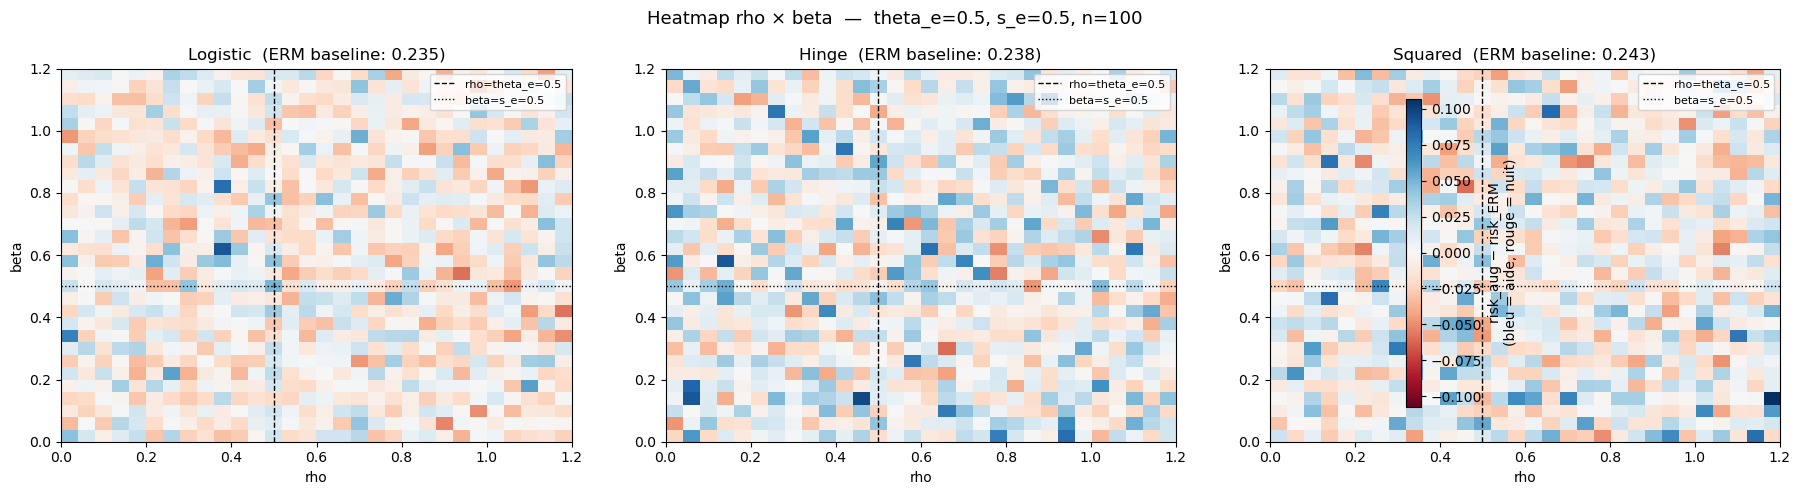

In [ ]:
# --- Plot : 1 ligne par loss ---
vmax = max(np.max(np.abs(g)) for g in diff_grids.values())
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, loss_names):
    im = ax.imshow(diff_grids[name], origin='lower', aspect='auto',
                   norm=norm, cmap='RdBu',
                   extent=[rho_values[0], rho_values[-1],
                           beta_values[0], beta_values[-1]])
    ax.axvline(theta_e, color='black', linestyle='--', linewidth=1,
               label=f'rho=theta_e={theta_e}')
    ax.axhline(s_e,     color='black', linestyle=':',  linewidth=1,
               label=f'beta=s_e={s_e}')
    ax.set_title(f'{name}  (ERM baseline: {risk_erm[name]:.3f})')
    ax.set_xlabel('rho')
    ax.set_ylabel('beta')
    ax.legend(fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.8, label='risk_aug − risk_ERM\n(bleu = aide, rouge = nuit)')
fig.suptitle(f'Heatmap rho × beta  —  theta_e={theta_e}, s_e={s_e}, n={n_train}',
             fontsize=13)
plt.tight_layout()
plt.savefig('images/rho_beta/heatmap_rho_beta_3losses.png', dpi=150)
plt.show()

## 13. Etude de la variation de rho et beta conjointement

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- RNGs ---
rng_train = np.random.default_rng(0)
rng_test  = np.random.default_rng(1)
rng_augm  = np.random.default_rng(42)

# --- Paramètres fixes ---
p       = 30
m       = 1.0
sigma   = 1.0
s_e     = 1   # shift additif nul — on isole l'effet rotation pur
beta    = 1   # pas d'augmentation en shift
lam     = 0.1
n_train = 300
n_test  = 2000
K_augm  = 30

loss1 = lr.LogisticLoss()
loss2 = lr.HingeLoss()
loss3 = lr.SquaredLoss()
losses     = [loss1, loss2, loss3]
loss_names = ['Logistic', 'Hinge', 'Squared']

reg = lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))
model_train = generate_source_model(p=p, delta=m, sigma=sigma)

rho_values    = np.linspace(0.0, 0.8, 15)
theta_e_values = np.linspace(0.0, 0.8, 15)

# --- Grille rho x theta_e ---
diff_grids = {name: np.zeros((len(theta_e_values), len(rho_values)))
              for name in loss_names}

for i, te in enumerate(theta_e_values):
    # modèle cible avec rotation te, pas de shift
    R_e = rotation(te, p)
    b_e = np.zeros(p)
    model_target = generate_target_model(p=p, delta=m, sigma=sigma,
                                         rotation=R_e, biais=b_e)
    # ERM baseline pour ce theta_e (ne dépend pas de rho)
    risk_erm_te = {}
    for loss, name in zip(losses, loss_names):
        theta_erm, _, _ = et.ERMTrainer(model=model_train, loss=loss, regularizer=reg)\
                            .sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=300)
        risk_erm_te[name] = model_target.error_classif_emp(
            [theta_erm], n_test=n_test, rng=rng_test
        )

    for j, rho_val in enumerate(rho_values):
        tr = make_transform(p=p, rho=rho_val, beta=beta, rng=rng_augm)
        for loss, name in zip(losses, loss_names):
            theta_aug, _, _ = augm.DataAugmTrainer(
                model=model_train, loss=loss, regularizer=reg,
                transform=tr, K_augm=K_augm
            ).sample_theta_hat(n=n_train, rng=rng_train, solver_maxiter=300)
            risk_aug = model_target.error_classif_emp(
                [theta_aug], n_test=n_test, rng=rng_test
            )
            diff_grids[name][i, j] = risk_aug - risk_erm_te[name]

C:\Users\grego\AppData\Local\Temp\ipykernel_6568\1240113517.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


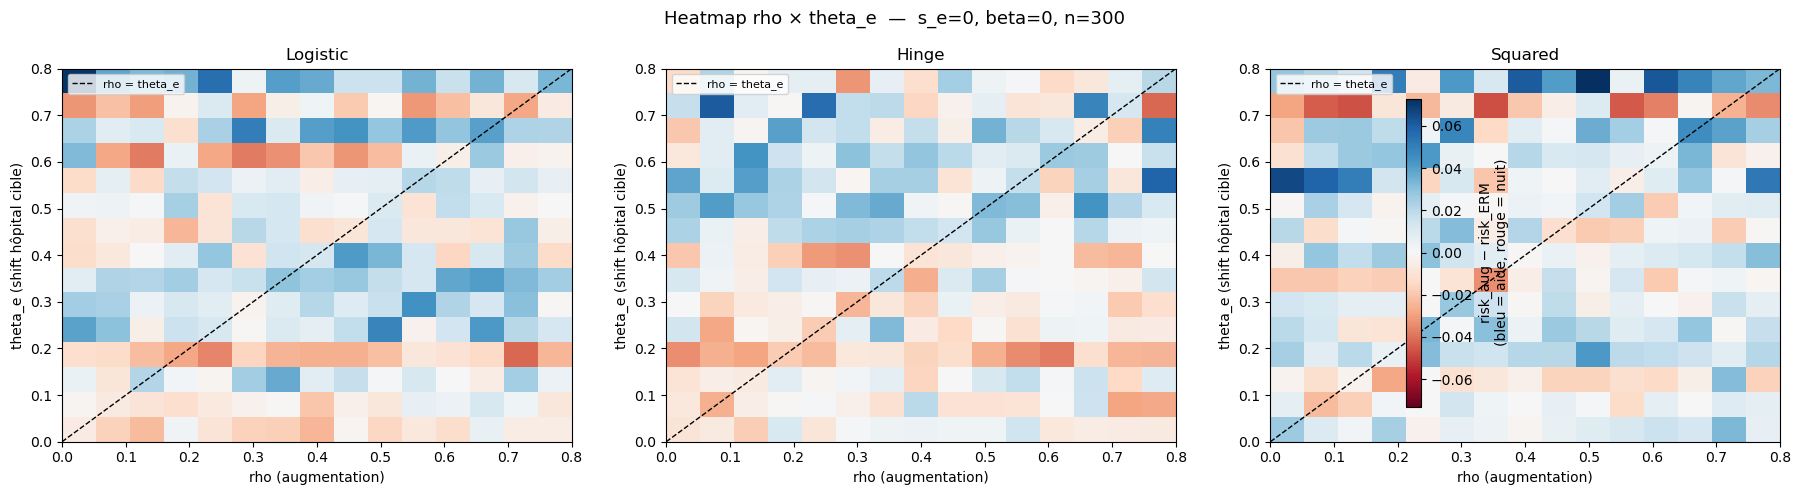

In [15]:
# --- Plot ---
vmax = max(np.max(np.abs(g)) for g in diff_grids.values())
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, loss_names):
    im = ax.imshow(diff_grids[name], origin='lower', aspect='auto',
                   norm=norm, cmap='RdBu',
                   extent=[rho_values[0], rho_values[-1],
                           theta_e_values[0], theta_e_values[-1]])
    # diagonale rho = theta_e
    ax.plot([0, 0.8], [0, 0.8], color='black', linestyle='--',
            linewidth=1, label='rho = theta_e')
    ax.set_title(f'{name}')
    ax.set_xlabel('rho (augmentation)')
    ax.set_ylabel('theta_e (shift hôpital cible)')
    ax.legend(fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.8,
             label='risk_aug − risk_ERM\n(bleu = aide, rouge = nuit)')
fig.suptitle(f'Heatmap rho × theta_e  —  s_e=0, beta=0, n={n_train}',
             fontsize=13)
plt.tight_layout()
plt.savefig('images/heatmap_rho_thetae_3losses.png', dpi=150)
plt.show()

## 14. Etude de la variation de n

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- RNGs ---
rng_train = np.random.default_rng(0)
rng_test  = np.random.default_rng(1)
rng_augm  = np.random.default_rng(42)

# --- Paramètres fixes ---
p       = 30
m       = 1.0
sigma   = 1.0
theta_e = 0.2
s_e     = 0.1
rho     = 0.2   # rho = theta_e — sweet spot théorique
beta    = 0.1   # beta = s_e
lam     = 0.1
n_test  = 2000
K_augm  = 30

loss1 = lr.LogisticLoss()
loss2 = lr.HingeLoss()
loss3 = lr.SquaredLoss()
losses     = [loss1, loss2, loss3]
loss_names = ['Logistic', 'Hinge', 'Squared']

reg = lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))

model_train = generate_source_model(p=p, delta=m, sigma=sigma)
R_e = rotation(theta_e, p)
b_e = np.zeros(p); b_e[1] = s_e
model_target = generate_target_model(p=p, delta=m, sigma=sigma,
                                     rotation=R_e, biais=b_e)

tr = make_transform(p=p, rho=rho, beta=beta, rng=rng_augm)

n_values = np.arange(20, 500, 50)

risk_erm  = {name: [] for name in loss_names}
risk_augm = {name: [] for name in loss_names}

for n in n_values:
    for loss, name in zip(losses, loss_names):
        theta_erm, _, _ = et.ERMTrainer(
            model=model_train, loss=loss, regularizer=reg
        ).sample_theta_hat(n=n, rng=rng_train, solver_maxiter=300)
        risk_erm[name].append(model_target.error_classif_emp(
            [theta_erm], n_test=n_test, rng=rng_test
        ))

        theta_aug, _, _ = augm.DataAugmTrainer(
            model=model_train, loss=loss, regularizer=reg,
            transform=tr, K_augm=K_augm
        ).sample_theta_hat(n=n, rng=rng_train, solver_maxiter=300)
        risk_augm[name].append(model_target.error_classif_emp(
            [theta_aug], n_test=n_test, rng=rng_test
        ))

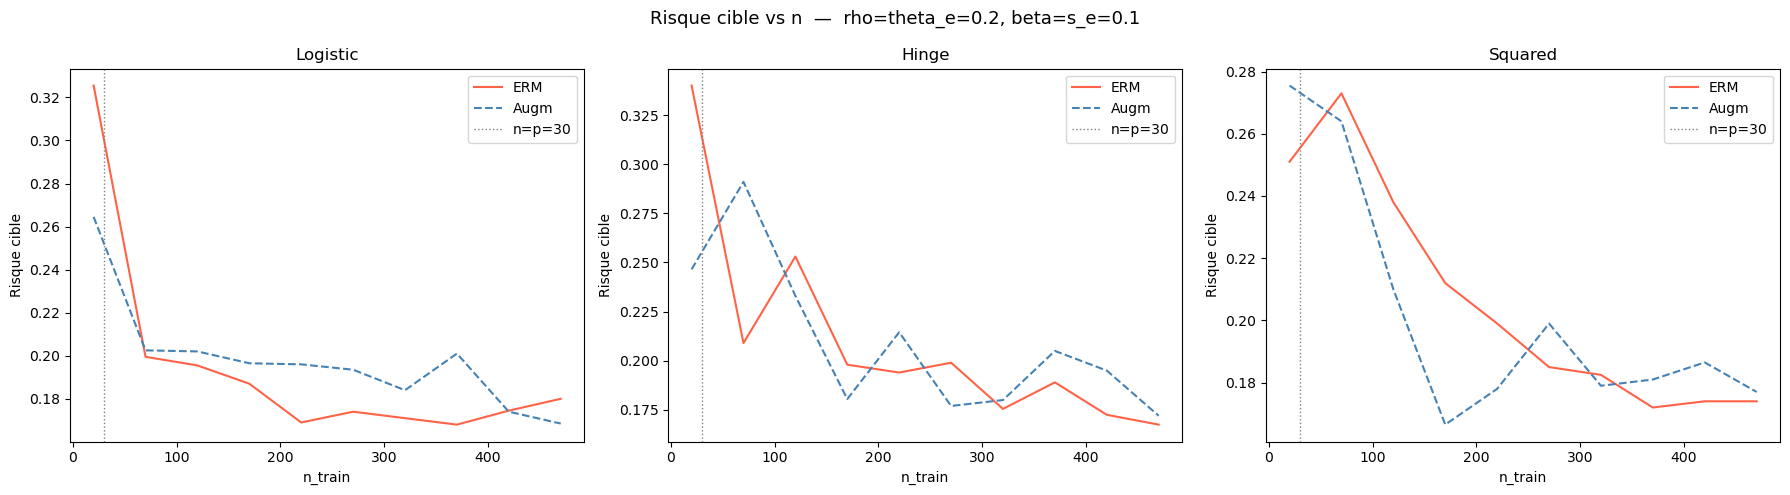

In [17]:
# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, loss_names):
    ax.plot(n_values, risk_erm[name],  label='ERM',  color='tomato')
    ax.plot(n_values, risk_augm[name], label='Augm', color='steelblue',
            linestyle='--')
    ax.axvline(p, color='gray', linestyle=':', linewidth=1, label=f'n=p={p}')
    ax.set_title(name)
    ax.set_xlabel('n_train')
    ax.set_ylabel('Risque cible')
    ax.legend()

fig.suptitle(f'Risque cible vs n  —  rho=theta_e={rho}, beta=s_e={beta}',
             fontsize=13)
plt.tight_layout()
plt.savefig('risque_vs_n.png', dpi=150)
plt.show()

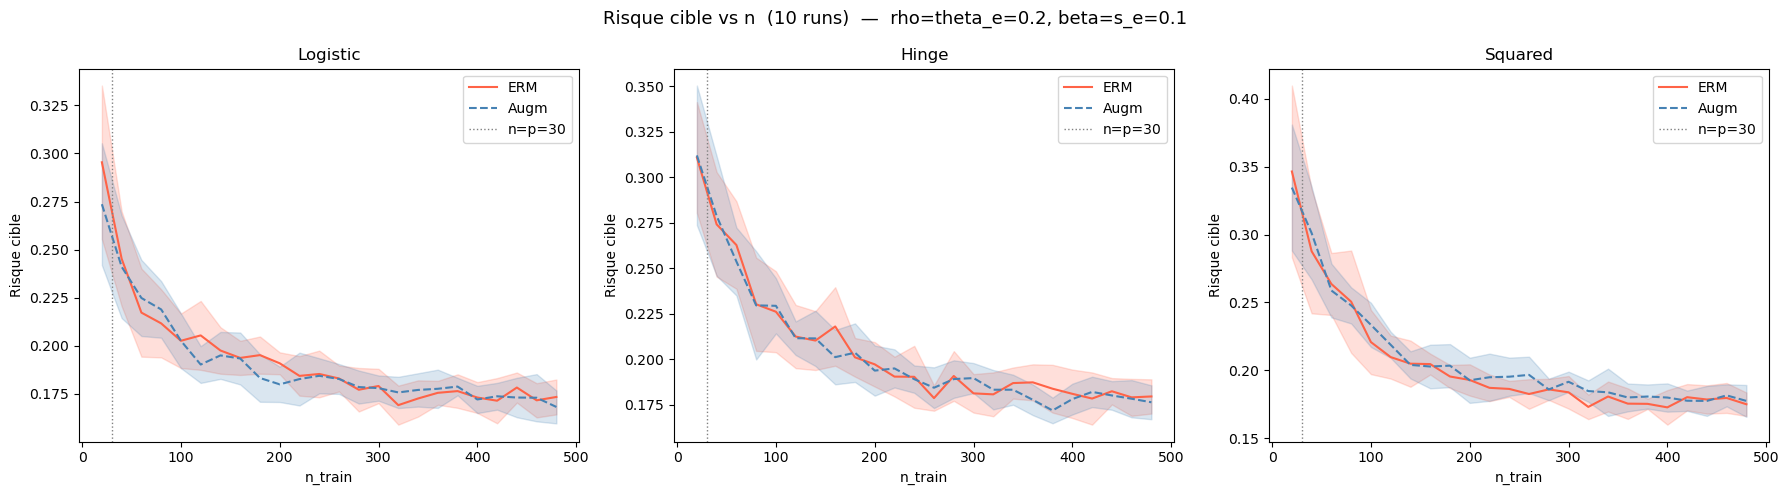

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- RNGs ---
rng_test  = np.random.default_rng(1)
rng_augm  = np.random.default_rng(42)

# --- Paramètres fixes ---
p       = 30
m       = 1.0
sigma   = 1.0
theta_e = 0.2
s_e     = 0.1
rho     = 0.2
beta    = 0.1
lam     = 0.1
n_test  = 2000
K_augm  = 30
N_runs  = 10

loss1 = lr.LogisticLoss()
loss2 = lr.HingeLoss()
loss3 = lr.SquaredLoss()
losses     = [loss1, loss2, loss3]
loss_names = ['Logistic', 'Hinge', 'Squared']

reg = lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))
model_train = generate_source_model(p=p, delta=m, sigma=sigma)
R_e = rotation(theta_e, p)
b_e = np.zeros(p); b_e[1] = s_e
model_target = generate_target_model(p=p, delta=m, sigma=sigma,
                                     rotation=R_e, biais=b_e)
tr = make_transform(p=p, rho=rho, beta=beta, rng=rng_augm)

n_values = np.arange(20, 481, 20)

# stocke les runs : shape (N_runs, len(n_values)) par loss
risk_erm_runs  = {name: np.zeros((N_runs, len(n_values))) for name in loss_names}
risk_augm_runs = {name: np.zeros((N_runs, len(n_values))) for name in loss_names}

for r in range(N_runs):
    rng_train_r = np.random.default_rng(r)  # seed différente par run
    for k, n in enumerate(n_values):
        for loss, name in zip(losses, loss_names):
            theta_erm, _, _ = et.ERMTrainer(
                model=model_train, loss=loss, regularizer=reg
            ).sample_theta_hat(n=n, rng=rng_train_r, solver_maxiter=300)
            risk_erm_runs[name][r, k] = model_target.error_classif_emp(
                [theta_erm], n_test=n_test, rng=rng_test
            )

            theta_aug, _, _ = augm.DataAugmTrainer(
                model=model_train, loss=loss, regularizer=reg,
                transform=tr, K_augm=K_augm
            ).sample_theta_hat(n=n, rng=rng_train_r, solver_maxiter=300)
            risk_augm_runs[name][r, k] = model_target.error_classif_emp(
                [theta_aug], n_test=n_test, rng=rng_test
            )

# --- Moyennes et écarts-types ---
risk_erm_mean  = {name: risk_erm_runs[name].mean(axis=0)  for name in loss_names}
risk_erm_std   = {name: risk_erm_runs[name].std(axis=0)   for name in loss_names}
risk_augm_mean = {name: risk_augm_runs[name].mean(axis=0) for name in loss_names}
risk_augm_std  = {name: risk_augm_runs[name].std(axis=0)  for name in loss_names}

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, loss_names):
    ax.plot(n_values, risk_erm_mean[name],  color='tomato',    label='ERM')
    ax.fill_between(n_values,
                    risk_erm_mean[name] - risk_erm_std[name],
                    risk_erm_mean[name] + risk_erm_std[name],
                    color='tomato', alpha=0.2)

    ax.plot(n_values, risk_augm_mean[name], color='steelblue', label='Augm',
            linestyle='--')
    ax.fill_between(n_values,
                    risk_augm_mean[name] - risk_augm_std[name],
                    risk_augm_mean[name] + risk_augm_std[name],
                    color='steelblue', alpha=0.2)

    ax.axvline(p, color='gray', linestyle=':', linewidth=1, label=f'n=p={p}')
    ax.set_title(name)
    ax.set_xlabel('n_train')
    ax.set_ylabel('Risque cible')
    ax.legend()

fig.suptitle(
    f'Risque cible vs n  ({N_runs} runs)  —  rho=theta_e={rho}, beta=s_e={beta}',
    fontsize=13)
plt.tight_layout()
plt.savefig('risque_vs_n_moyennes.png', dpi=150)
plt.show()

## 15. Etude de la variation de n et rho conjointement

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- RNGs ---
rng_test  = np.random.default_rng(1)
rng_augm  = np.random.default_rng(42)

# --- Paramètres fixes ---
p       = 30
m       = 1.0
sigma   = 1.0
theta_e = 0.4   # grand shift pour être dans la zone intéressante
s_e     = 0.0
beta    = 0.0
lam     = 0.1
n_test  = 2000
K_augm  = 30

loss1 = lr.LogisticLoss()
loss2 = lr.HingeLoss()
loss3 = lr.SquaredLoss()
losses     = [loss1, loss2, loss3]
loss_names = ['Logistic', 'Hinge', 'Squared']

reg = lr.QuadraticRegularizer(a=np.zeros(p), H=lam * np.eye(p))
model_train = generate_source_model(p=p, delta=m, sigma=sigma)
R_e = rotation(theta_e, p)
b_e = np.zeros(p)
model_target = generate_target_model(p=p, delta=m, sigma=sigma,
                                     rotation=R_e, biais=b_e)

rho_values = np.linspace(0.0, 1.4, 30)
n_values   = np.arange(20, 600, 50)

diff_grids = {name: np.zeros((len(n_values), len(rho_values)))
              for name in loss_names}

for i, n in enumerate(n_values):
    rng_train = np.random.default_rng(0)
    # ERM baseline pour ce n
    risk_erm_n = {}
    for loss, name in zip(losses, loss_names):
        theta_erm, _, _ = et.ERMTrainer(
            model=model_train, loss=loss, regularizer=reg
        ).sample_theta_hat(n=n, rng=rng_train, solver_maxiter=300)
        risk_erm_n[name] = model_target.error_classif_emp(
            [theta_erm], n_test=n_test, rng=rng_test
        )

    for j, rho_val in enumerate(rho_values):
        tr = make_transform(p=p, rho=rho_val, beta=beta, rng=rng_augm)
        for loss, name in zip(losses, loss_names):
            theta_aug, _, _ = augm.DataAugmTrainer(
                model=model_train, loss=loss, regularizer=reg,
                transform=tr, K_augm=K_augm
            ).sample_theta_hat(n=n, rng=rng_train, solver_maxiter=300)
            risk_aug = model_target.error_classif_emp(
                [theta_aug], n_test=n_test, rng=rng_test
            )
            diff_grids[name][i, j] = risk_aug - risk_erm_n[name]

C:\Users\grego\AppData\Local\Temp\ipykernel_6568\1175722146.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


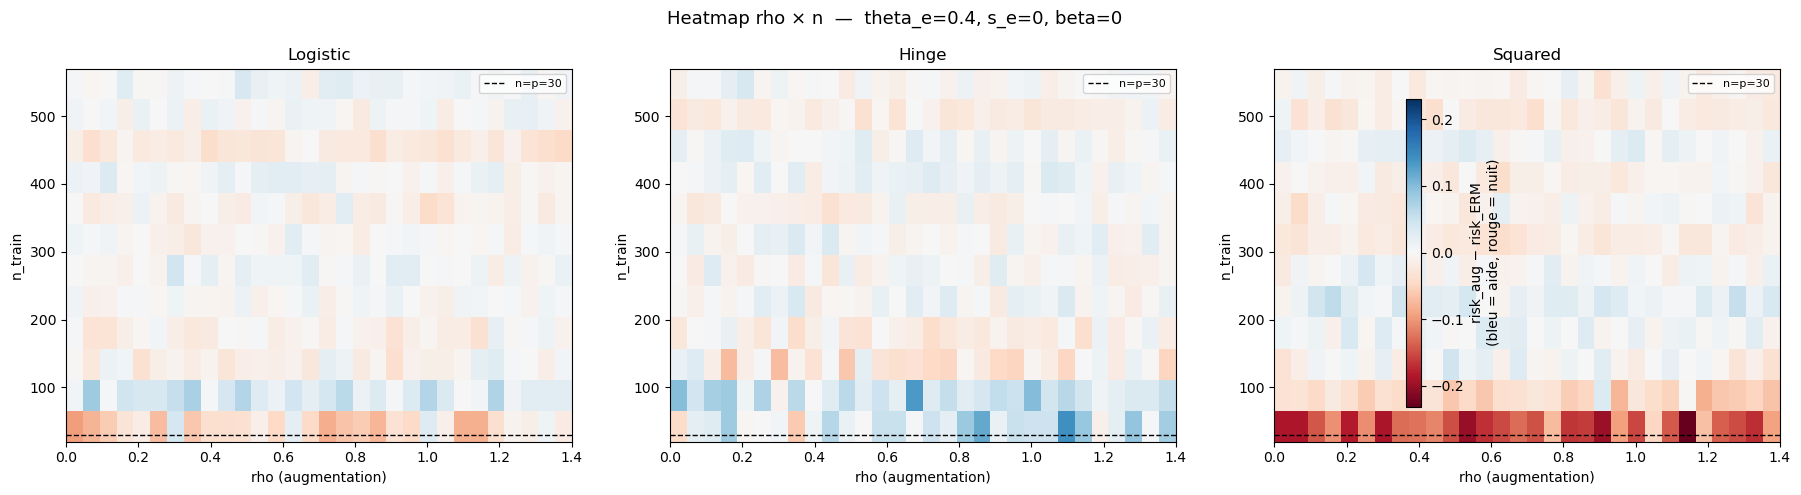

In [20]:
# --- Plot ---
vmax = max(np.max(np.abs(g)) for g in diff_grids.values())
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, loss_names):
    im = ax.imshow(diff_grids[name], origin='lower', aspect='auto',
                   norm=norm, cmap='RdBu',
                   extent=[rho_values[0], rho_values[-1],
                           n_values[0],   n_values[-1]])
    ax.axhline(p, color='black', linestyle='--', linewidth=1,
               label=f'n=p={p}')
    ax.set_title(name)
    ax.set_xlabel('rho (augmentation)')
    ax.set_ylabel('n_train')
    ax.legend(fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.8,
             label='risk_aug − risk_ERM\n(bleu = aide, rouge = nuit)')
fig.suptitle(f'Heatmap rho × n  —  theta_e={theta_e}, s_e=0, beta=0',
             fontsize=13)
plt.tight_layout()
plt.savefig('heatmap_rho_n.png', dpi=150)
plt.show()

In [21]:
import numpy as np
from scipy.linalg import expm

def random_rotation_from_identity(n, rng, theta=1.0):
    A = rng.standard_normal((n, n))
    K = (A - A.T) / 2
    K = K / np.linalg.norm(K, ord='fro')  # normalisé
    return expm(theta * K)

# Vérifie ||R - I||_F pour différentes valeurs de theta
rng = np.random.default_rng(0)
p = 30

print("theta   ||R-I||_F   ||R-I||_2   det(R)")
print("-" * 50)
for theta in [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]:
    norms_fro = []
    norms_2   = []
    dets      = []
    for _ in range(50):  # moyenne sur 50 tirages
        R = random_rotation_from_identity(p, rng=rng, theta=theta)
        eps = R - np.eye(p)
        norms_fro.append(np.linalg.norm(eps, ord='fro'))
        norms_2.append(np.linalg.norm(eps, ord=2))
        dets.append(np.linalg.det(R))
    print(f"theta={theta:.2f}  ||R-I||_F={np.mean(norms_fro):.4f}±{np.std(norms_fro):.4f}"
          f"  ||R-I||_2={np.mean(norms_2):.4f}  det={np.mean(dets):.6f}")

theta   ||R-I||_F   ||R-I||_2   det(R)
--------------------------------------------------
theta=0.01  ||R-I||_F=0.0100±0.0000  ||R-I||_2=0.0033  det=1.000000
theta=0.05  ||R-I||_F=0.0500±0.0000  ||R-I||_2=0.0167  det=1.000000
theta=0.10  ||R-I||_F=0.1000±0.0000  ||R-I||_2=0.0335  det=1.000000
theta=0.20  ||R-I||_F=0.2000±0.0000  ||R-I||_2=0.0672  det=1.000000
theta=0.40  ||R-I||_F=0.3998±0.0000  ||R-I||_2=0.1331  det=1.000000
theta=0.60  ||R-I||_F=0.5994±0.0000  ||R-I||_2=0.1998  det=1.000000
theta=0.80  ||R-I||_F=0.7986±0.0001  ||R-I||_2=0.2657  det=1.000000
theta=1.00  ||R-I||_F=0.9972±0.0001  ||R-I||_2=0.3310  det=1.000000
theta=1.50  ||R-I||_F=1.4905±0.0005  ||R-I||_2=0.4969  det=1.000000
theta=2.00  ||R-I||_F=1.9780±0.0011  ||R-I||_2=0.6486  det=1.000000


Point fixe ERM convergé : False  iter=1000
  mu_star[0]=1.0797  mu_star[1]=-0.0059  alpha=[0.38752397 0.38752397]


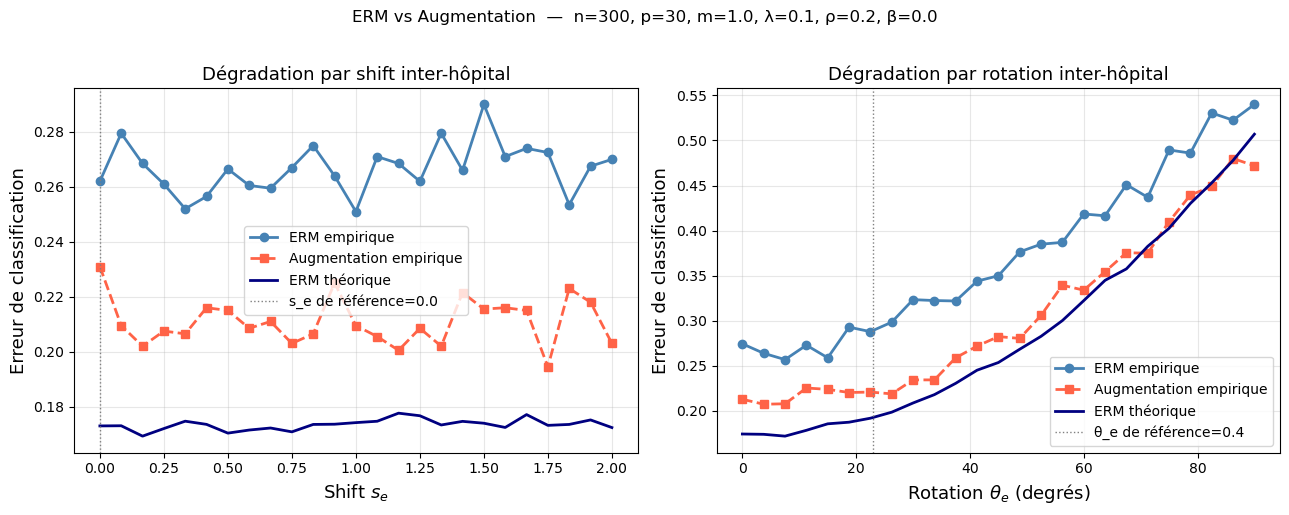

In [22]:
## ── Sweep comparaison ERM vs Augmentation ──────────────────────────────────

# ── Point fixe ERM (une fois sur le source) ──
solver1 = et.TheoryFixedPointSolver(
    model=model_train, loss=loss1, regularizer=reg,
    n_train=n_train, mc_samples=10000, rng=np.random.default_rng(42)
)
th1 = solver1.solve(max_iter=1000, tol=1e-5, damping=0.1, verbose=False)
print(f"Point fixe ERM convergé : {th1['converged']}  iter={th1['num_iter']}")
print(f"  mu_star[0]={th1['mu'][0]:.4f}  mu_star[1]={th1['mu'][1]:.4f}  alpha={th1['alpha']}")

# ── Sweep sur s_e (shift) ─────────────────────────────────────────────────
s_grid   = np.linspace(0.0, 2.0, 25)
theta_e_fixed = 0.0
R_fixed  = rotation(theta_e_fixed, p)

emp_erm_s  = []
emp_aug_s  = []
th_erm_s   = []

for s_e_val in s_grid:
    b = np.zeros(p); b[1] = s_e_val
    mt = generate_target_model(sigma=sigma, p=p, delta=m,
                                rotation=R_fixed, biais=b)
    # empirique ERM
    emp_erm_s.append(mt.error_classif_emp([theta_hat1],       n_test=n_test, rng=rng_test))
    # empirique augmenté
    emp_aug_s.append(mt.error_classif_emp([theta_hat1_augm],  n_test=n_test, rng=rng_test))
    # théorique ERM
    th_erm_s.append( mt.error_classif_th(th1["mu"], th1["alpha"], num_trials=50000))

# ── Sweep sur theta_e (rotation) ──────────────────────────────────────────
theta_grid = np.linspace(0.0, np.pi/2, 25)
s_e_fixed  = 0.0
b_fixed    = np.zeros(p); b_fixed[1] = s_e_fixed

emp_erm_r  = []
emp_aug_r  = []
th_erm_r   = []

for th_e_val in theta_grid:
    R = rotation(th_e_val, p)
    mt = generate_target_model(sigma=sigma, p=p, delta=m,
                                rotation=R, biais=b_fixed)
    emp_erm_r.append(mt.error_classif_emp([theta_hat1],       n_test=n_test, rng=rng_test))
    emp_aug_r.append(mt.error_classif_emp([theta_hat1_augm],  n_test=n_test, rng=rng_test))
    th_erm_r.append( mt.error_classif_th(th1["mu"], th1["alpha"], num_trials=50000))

# ── Graphiques ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Sweep shift ---
ax = axes[0]
ax.plot(s_grid, emp_erm_s, 'o-',  color='steelblue',  label='ERM empirique',        lw=2)
ax.plot(s_grid, emp_aug_s, 's--', color='tomato',     label='Augmentation empirique', lw=2)
ax.plot(s_grid, th_erm_s,  '-',   color='navy',       label='ERM théorique',          lw=2)
ax.axvline(s_e, color='gray', ls=':', lw=1, label=f's_e de référence={s_e}')
ax.set_xlabel('Shift $s_e$', fontsize=13)
ax.set_ylabel('Erreur de classification', fontsize=13)
ax.set_title('Dégradation par shift inter-hôpital', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Sweep rotation ---
ax = axes[1]
ax.plot(np.degrees(theta_grid), emp_erm_r, 'o-',  color='steelblue',  label='ERM empirique',         lw=2)
ax.plot(np.degrees(theta_grid), emp_aug_r, 's--', color='tomato',     label='Augmentation empirique', lw=2)
ax.plot(np.degrees(theta_grid), th_erm_r,  '-',   color='navy',       label='ERM théorique',           lw=2)
ax.axvline(np.degrees(theta_e), color='gray', ls=':', lw=1, label=f'θ_e de référence={theta_e}')
ax.set_xlabel('Rotation $\\theta_e$ (degrés)', fontsize=13)
ax.set_ylabel('Erreur de classification', fontsize=13)
ax.set_title('Dégradation par rotation inter-hôpital', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle(f'ERM vs Augmentation  —  n={n_train}, p={p}, m={m}, λ={lam}, ρ={rho}, β={beta}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("sweep_erm_vs_augm.png", dpi=150, bbox_inches='tight')
plt.show()